 Image loaded. Applying Custom Histogram Equalization...


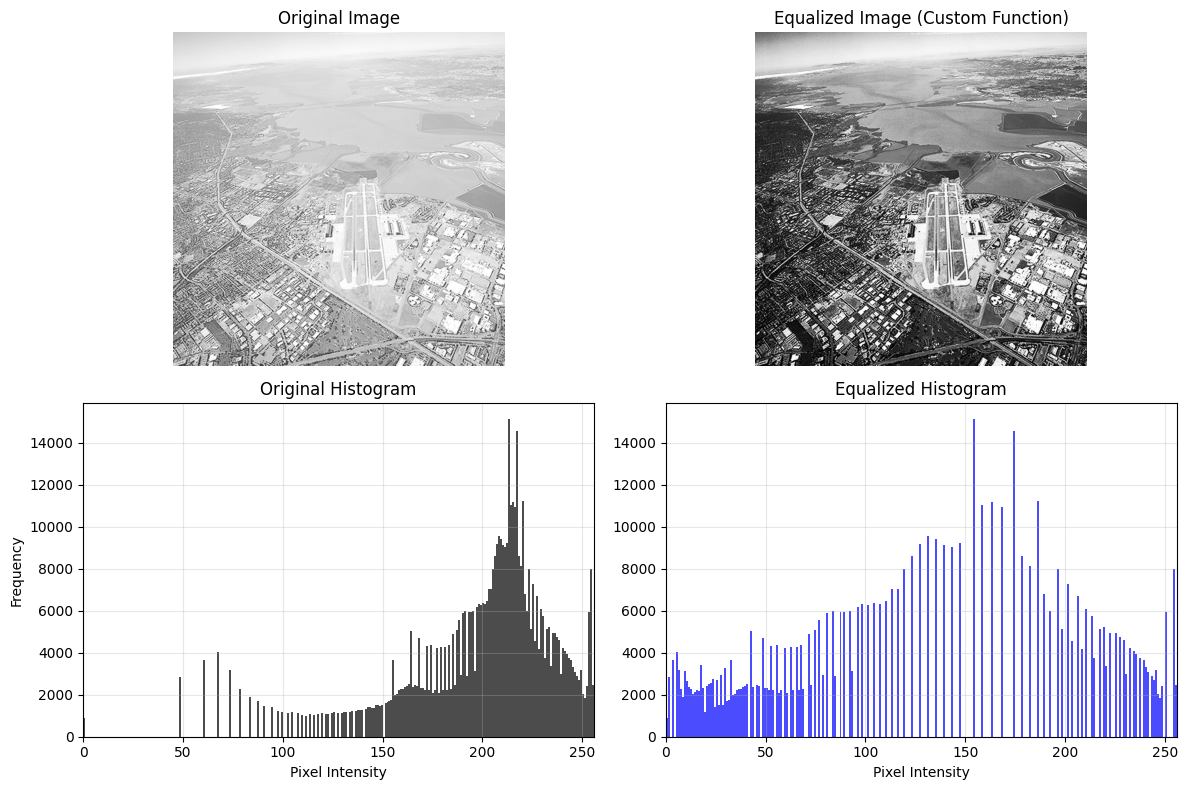

In [2]:
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt


# Custom Function
def custom_hist_equalization(img):
    # 1. Compute Histogram manually
    histogram = np.zeros(256 , dtype=int)
    rows , cols = img.shape
    total_pixels = rows * cols

    flat_img = img.flatten()
    for pixel_value in flat_img:
        histogram[pixel_value] += 1

    #  Compute CDF 
    cdf = np.zeros(256 , dtype=float)
    cdf[0] = histogram[0]
    for i in range(1 , 256):
        cdf[i] = cdf[i - 1] + histogram[i]

    
    cdf_min = cdf[np.nonzero(cdf)][0]  # Find first non-zero value
    lut = np.zeros(256 , dtype="uint8")

    for i in range(256):
        if cdf[i] > 0:
            value = round(((cdf[i] - cdf_min) / (total_pixels - cdf_min)) * 255)
            lut[i] = max(0 , min(255 , value)) 
        else:
            lut[i] = 0

    
    equalized_img = cv.LUT(img , lut)
    return equalized_img , lut




file_path = r"d:\computer_Vision_Inclass_11_26\runway.png"
img = cv.imread(file_path , cv.IMREAD_GRAYSCALE)

if img is None:
    print(" ERROR: Image not found.")
else:
    print(" Image loaded. Applying Custom Histogram Equalization...")
    img_eq , lut = custom_hist_equalization(img)

    plt.figure(figsize=(12 , 8))

    #  Original Image
    plt.subplot(2 , 2 , 1)
    plt.imshow(img , cmap='gray' , vmin=0 , vmax=255)
    plt.title('Original Image')
    plt.axis('off')

    #  Equalized Image
    plt.subplot(2 , 2 , 2)
    plt.imshow(img_eq , cmap='gray' , vmin=0 , vmax=255)
    plt.title('Equalized Image (Custom Function)')
    plt.axis('off')

    #  Original Histogram 
    plt.subplot(2 , 2 , 3)
    plt.hist(img.flatten() , bins=256 , range=[0 , 256] , color='black' , alpha=0.7)
    plt.title('Original Histogram')
    plt.xlabel('Pixel Intensity')
    plt.ylabel('Frequency')
    plt.xlim([0 , 256])
    plt.grid(True , alpha=0.3)

    #  Equalized Histogram 
    plt.subplot(2 , 2 , 4)
    plt.hist(img_eq.flatten() , bins=256 , range=[0 , 256] , color='blue' , alpha=0.7)
    plt.title('Equalized Histogram')
    plt.xlabel('Pixel Intensity')
    plt.xlim([0 , 256])
    plt.grid(True , alpha=0.3)

    plt.tight_layout()
    plt.show()